In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


*Goal: understand what each step does conceptually, not memorize the syntax — syntax can always be looked up.*

In [2]:
data = pd.read_csv("car_data(in).csv")

data.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [4]:
# Check for null values per column
# (without .sum(), this would return a True/False DataFrame for every cell instead)
data.isnull().sum()


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [5]:
# Summary statistics: mean, std, min, max, etc.
# The 25/50/75% rows are percentiles - e.g. 25% means 25% of values in that column fall below it
# 'count' is the number of non-null values
data.describe()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
data.columns


Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='str')

In [7]:
# Count of each category in the categorical columns
print(data['Fuel_Type'].value_counts())
print(data['Seller_Type'].value_counts())
print(data['Transmission'].value_counts())

fuel_type = data['Fuel_Type']
seller_type = data['Seller_Type']
transmission_type = data['Transmission']
selling_price = data['Selling_Price']


Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


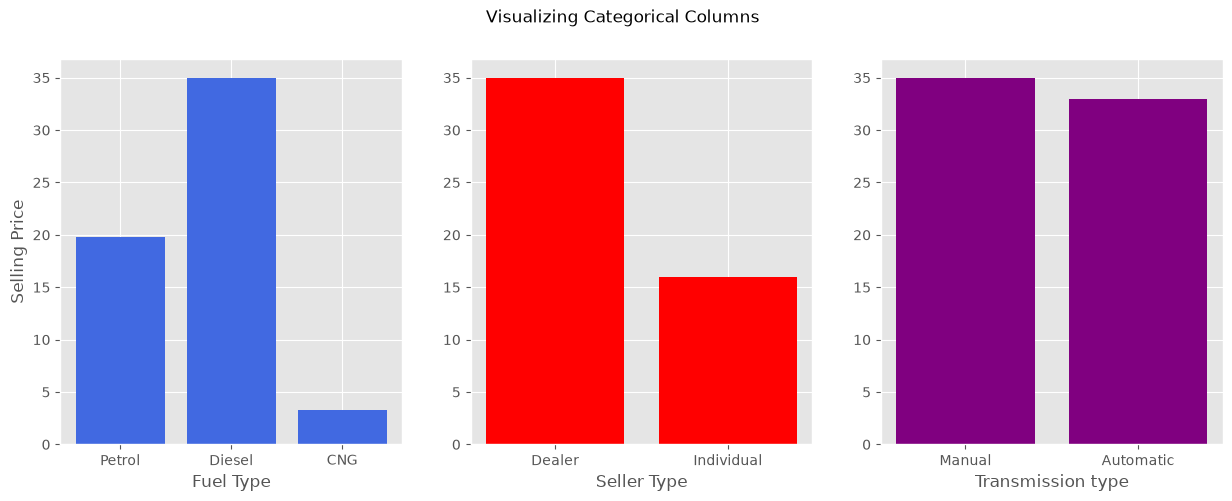

In [8]:
from matplotlib import style
style.use('ggplot')  # nicer default styling

fig = plt.figure(figsize=(15, 5))  # 15in wide x 5in tall
fig.suptitle('Visualizing Categorical Columns')

plt.subplot(1, 3, 1)  # 1x3 grid, position 1
plt.bar(fuel_type, selling_price, color=['royalblue'])
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.subplot(1, 3, 2)  # 1x3 grid, position 2
plt.bar(seller_type, selling_price, color='red')
plt.xlabel("Seller Type")

plt.subplot(1, 3, 3)  # 1x3 grid, position 3
plt.bar(transmission_type, selling_price, color='purple')
plt.xlabel('Transmission type')

plt.show()

# plt.* calls apply to whichever figure/subplot is currently active -
# that's set up by plt.figure() and plt.subplot() above, so there's no
# need to reference `fig` directly for each plotting call.


<Axes: xlabel='Transmission', ylabel='Selling_Price'>

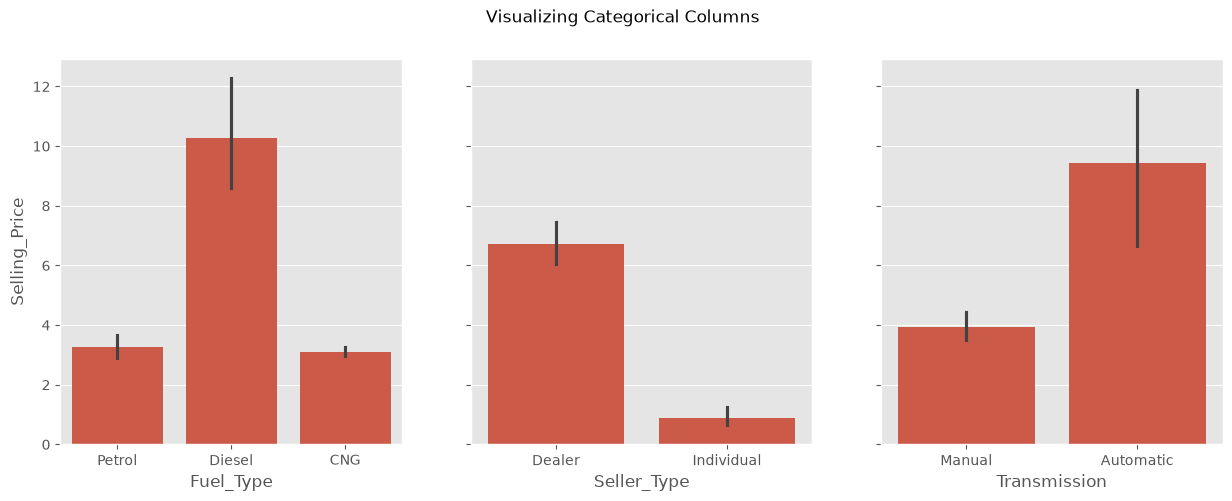

In [9]:
# sharey=True makes all subplots share the same y-axis scale, which makes
# them easier to compare directly. Here it doesn't change much since
# selling_price is the same across all three subplots, but it's good practice.

# Note: the title is set on `fig` (fig.suptitle) rather than on an individual
# axis, since it applies to the whole figure, not to any single subplot.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Visualizing Categorical Columns')

sns.barplot(x=fuel_type, y=selling_price, ax=axes[0])   # equivalent to subplot(1,3,1)
sns.barplot(x=seller_type, y=selling_price, ax=axes[1]) # equivalent to subplot(1,3,2)
sns.barplot(x=transmission_type, y=selling_price, ax=axes[2]) # equivalent to subplot(1,3,3)


In [10]:
# Isolate petrol cars and view their summary statistics
petrol_data = data.groupby('Fuel_Type').get_group('Petrol')
petrol_data.describe()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,239.000000,239.000000,239.000000,239.000000,239.000000
mean,2013.539749,3.264184,5.583556,33528.937238,0.050209
std,3.042674,3.135537,5.290685,40308.984886,0.270368
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.600000,0.940000,13850.000000,0.000000
50%,2014.000000,2.650000,4.600000,25870.000000,0.000000
75%,2016.000000,5.200000,7.980000,44271.000000,0.000000
max,2017.000000,19.750000,23.730000,500000.000000,3.000000


In [11]:
# Isolate dealer-sold cars and view their summary statistics
seller_data = data.groupby('Seller_Type').get_group('Dealer')
seller_data.describe()


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,195.000000,195.000000,195.000000,195.000000,195.000000
mean,2013.712821,6.721692,10.886308,39850.133333,0.020513
std,2.686275,5.136088,8.806563,24860.401003,0.142111
min,2003.000000,1.050000,2.690000,2071.000000,0.000000
25%,2012.000000,3.750000,6.580000,22148.500000,0.000000
50%,2014.000000,5.250000,8.500000,39485.000000,0.000000
75%,2016.000000,7.625000,13.460000,51785.500000,0.000000
max,2018.000000,35.000000,92.600000,197176.000000,1.000000


In [12]:
# Encode categorical columns as numeric values
data.replace({'Fuel_Type': {'Petrol': 0, 'Diesel': 1, 'CNG': 2}}, inplace=True)
data.replace({'Seller_Type': {'Dealer': 0, 'Individual': 1}}, inplace=True)
data.replace({'Transmission': {'Manual': 0, 'Automatic': 1}}, inplace=True)

data.head()


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


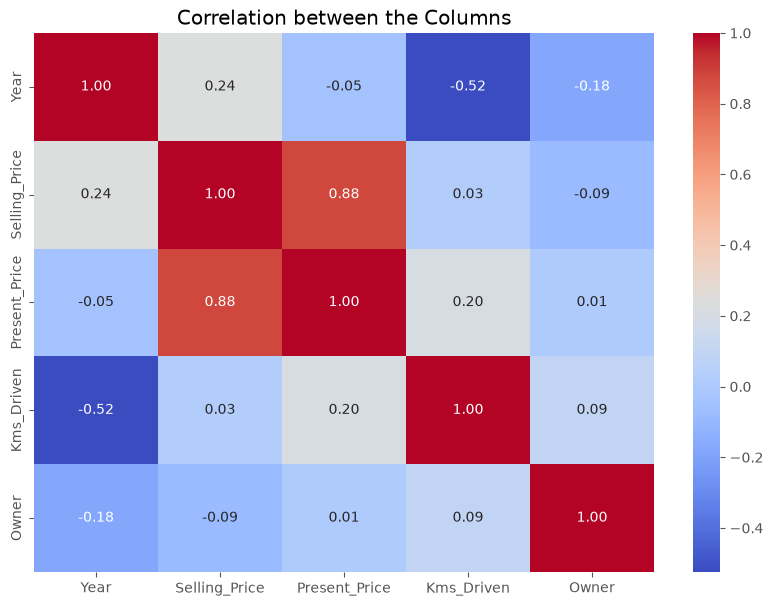

In [13]:
plt.figure(figsize=(10, 7))
sns.heatmap(data.select_dtypes(include=['number']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation between the Columns')
plt.show()

# Correlation here is the Pearson coefficient, which measures *linear* relationships:
# +1 = as A increases, B increases | -1 = as A increases, B decreases | 0 = no linear relationship

# This method misses non-linear relationships - e.g. a U-shaped curve can show a
# correlation near zero even though the variables are clearly related.


<Axes: title={'center': 'Correlation between Present price and Selling price'}, xlabel='Present_Price', ylabel='Selling_Price'>

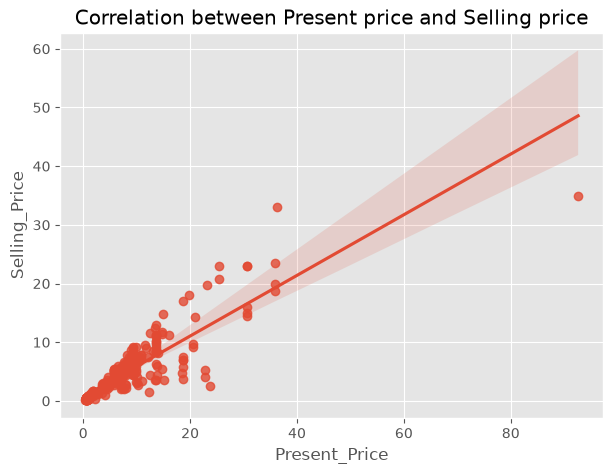

In [14]:
fig = plt.figure(figsize=(7, 5))
plt.title('Correlation between Present price and Selling price')

# regplot draws a scatter plot plus a fitted regression line, useful for
# visualizing the trend and strength of the relationship between two
# continuous variables.
sns.regplot(x='Present_Price', y='Selling_Price', data=data)


In [15]:
# X: input features used to make the prediction (drop Car_Name since it's
# just an identifier, and drop Selling_Price since that's the target)
X = data.drop(['Car_Name', 'Selling_Price'], axis=1)

# y: the target variable we want the model to learn to predict
y = data["Selling_Price"]

X.shape
y.shape


(301,)

In [16]:
from sklearn.model_selection import train_test_split

# Splits the dataset into training and testing sets.
# X_train/y_train are used to train the model; X_test/y_test are held out
# to evaluate it on data it hasn't seen. test_size=0.3 means 30% test / 70% train.
# random_state=43 makes the split reproducible.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=43)


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# StandardScaler rescales features to a similar range so no single feature
# (e.g. price vs. mileage) dominates the model just because of its raw scale.
# This isn't training the model itself - it's a preprocessing step that helps
# the model learn the X-y relationship rather than being skewed by feature magnitude.

# fit_transform learns the scaling parameters from the training set;
# transform then applies those same parameters to the test set, so test
# data never influences training.
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Note: y_test plays no role in training - it's only used afterward to
# score the model's predictions.


In [18]:
from sklearn.linear_model import LinearRegression

# LinearRegression fits a straight-line relationship between the input
# features and the target value.


In [19]:
linreg = LinearRegression()

# Model object created but not yet trained


In [20]:
# fit() trains the model: it learns the mapping from car features to selling price
linreg.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 1.01, 3.6 ,-0.37,...,-0.66, 0.59,-0.25]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.577
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[21.29,18.46,14.97,...,11.35, 9.65, 7.78]"


In [21]:
# Use the trained model to predict prices on the held-out test set,
# then compare these predictions against the real values in y_test
y_pred = linreg.predict(X_test)


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE: ", (mean_absolute_error(y_pred, y_test)))
print("MSE: ", (mean_squared_error(y_pred, y_test)))
print("R2 score: ", r2_score(y_test, y_pred))  # r2_score expects (y_true, y_pred) - order matters
# MAE and MSE are symmetric so argument order doesn't affect them, but it's
# best practice to keep the order consistent everywhere to avoid mistakes.


MAE:  1.4308902766497646
MSE:  5.167492869813312
R2 score:  0.838554949162385


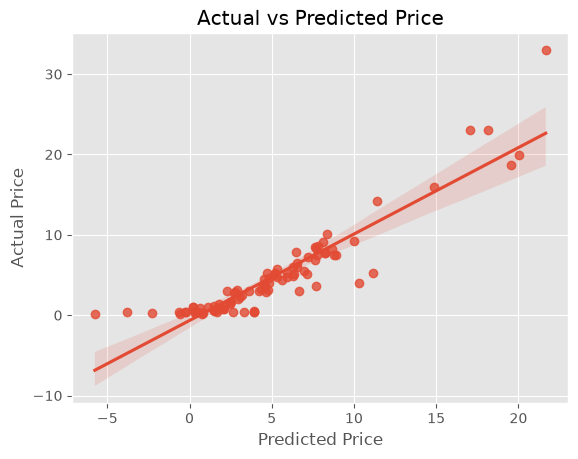

In [23]:
sns.regplot(x=y_pred, y=y_test)
plt.xlabel("Predicted Price")
plt.ylabel('Actual Price')
plt.title("Actual vs Predicted Price")
plt.show()


Columns removed because they have very low correlation:
['Kms_Driven', 'Owner']


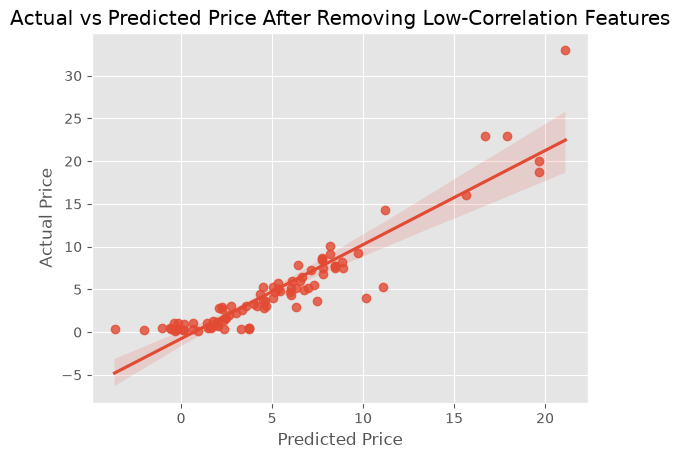

In [24]:
# Try a second model after removing features with very low correlation with the target
# This is a simple feature-selection step to improve the model

corr_with_target = data.select_dtypes(include=['number']).corr()['Selling_Price'].drop('Selling_Price').abs()

# Keep only columns with correlation greater than 0.1 with Selling_Price
low_corr_cols = corr_with_target[corr_with_target < 0.1].index.tolist()

print('Columns removed because they have very low correlation:')
print(low_corr_cols)

# Create a new dataset without those weak features
data_filtered = data.drop(columns=low_corr_cols)

# Define features and target again for the filtered data
X_filtered = data_filtered.drop(['Car_Name', 'Selling_Price'], axis=1)
y_filtered = data_filtered['Selling_Price']

# Split the filtered data into train and test sets
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_filtered, y_filtered, test_size=0.3, random_state=43
)

# Scale the filtered features
scaler_f = StandardScaler()
X_train_f = scaler_f.fit_transform(X_train_f)
X_test_f = scaler_f.transform(X_test_f)

# Train the model again on the filtered data
linreg_filtered = LinearRegression()
linreg_filtered.fit(X_train_f, y_train_f)

# Predict on the test set
y_pred_filtered = linreg_filtered.predict(X_test_f)

# Plot actual vs predicted after feature selection
sns.regplot(x=y_pred_filtered, y=y_test_f)
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Actual vs Predicted Price After Removing Low-Correlation Features')
plt.show()

In [25]:
print("R2 score (filtered): ", (r2_score( y_test_f,y_pred_filtered)))

R2 score (filtered):  0.8459385766623752
